# Using the AHRS Kalman filter

This is a small illustration of how to use the AHRS Kalman filter from NXP, packaged by Adafruit. See the references / links / source repos at:

- https://github.com/adafruit/Adafruit_AHRS
- https://www.nxp.com/company/about-nxp/smarter-world-blog/BL-OPEN-SOURCE-SENSOR-FUSION
- https://www.nxp.com/docs/en/data-sheet/NSFK_DS.pdf

The Kalman filter (KF) AHRS filter is used e.g. in the OpenMetBuoy (https://github.com/jerabaul29/OpenMetBuoy-v2021a).

This is made easy to use on PCs through the wrappers of GauteH:

- https://github.com/gauteh/ahrs-fusion

The data used here to illustrate the algorithm were obtained in a research project and presented in the article:

"Measurements of Waves in Landfast Ice Using Inertial Motion Units"
Jean Rabault; Graig Sutherland; Brian Ward; Kai H. Christensen; Trygve Halsne; Atle Jensen
IEEE Transactions on Geoscience and Remote Sensing
2016

Note that there are many ways to shoot oneself in the feet, among others:

- units: m/s/s vs g; rad vs deg; g vs uT; etc
- orientations and signs (acceleration of the measurement chip vs. acceleration felt by the chip; there is a sign difference!)
- acceleration of the body vs. felt acceleration, in particular with gravity
- conventions in quaternion terms order

You will need to install GauteH's ahrs-fusion python wrappers first! For example on my machine:
```bash
~/Desktop/Git/ahrs-fusion [main|✔]> cargo +nightly install --path .
/Desktop/Git/ahrs-fusion/python [main|✔]> rustup default nightly
~/Desktop/Git/ahrs-fusion/python [main|✔]> pip install .
```

In [1]:
from ahrs_fusion import NxpFusion
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

In [2]:
# load the data, parse the time column
pl_data = pl.read_csv("./VN1002_XYZ.csv")
pl_data = pl_data.with_columns(datetime = pl.col("timestamp").str.to_datetime())

In [3]:
pl_data

timestamp,VN1002_acc_x_m/s/s,VN1002_acc_y_m/s/s,VN1002_acc_z_m/s/s,VN1002_ang_x_rad/s,VN1002_ang_y_rad/s,VN1002_ang_z_rad/s,VN1002_mag_x_ga,VN1002_mag_y_ga,VN1002_mag_z_ga,datetime
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,datetime[μs]
"""2015-03-26 18:23:00.800""",0.0249,-0.010687,-9.751356,-0.000441,0.000167,-0.000118,0.033053,0.042095,0.423619,2015-03-26 18:23:00.800
"""2015-03-26 18:23:00.900""",0.033862,-0.014417,-9.731705,-0.000503,-0.000349,0.000264,0.032018,0.042995,0.424241,2015-03-26 18:23:00.900
"""2015-03-26 18:23:01.000""",0.04676,-0.000051,-9.755948,-0.001313,-0.001012,0.000127,0.031953,0.042393,0.42542,2015-03-26 18:23:01
"""2015-03-26 18:23:01.100""",0.031048,-0.009983,-9.768954,-0.000877,-0.000263,0.000036,0.033045,0.042974,0.424289,2015-03-26 18:23:01.100
"""2015-03-26 18:23:01.200""",0.011062,-0.019936,-9.761791,-0.000224,-0.000546,0.000489,0.031392,0.040234,0.425236,2015-03-26 18:23:01.200
…,…,…,…,…,…,…,…,…,…,…
"""2015-03-26 18:53:00.300""",-0.045806,-0.022211,-9.767908,-0.00056,0.003937,-0.000077,0.033186,0.040907,0.423946,2015-03-26 18:53:00.300
"""2015-03-26 18:53:00.400""",-0.036557,-0.003129,-9.758292,-0.000646,0.004629,-0.000575,0.035245,0.043361,0.424678,2015-03-26 18:53:00.400
"""2015-03-26 18:53:00.500""",-0.022753,-0.024198,-9.771957,-0.000643,0.003985,0.000727,0.037381,0.043172,0.422157,2015-03-26 18:53:00.500


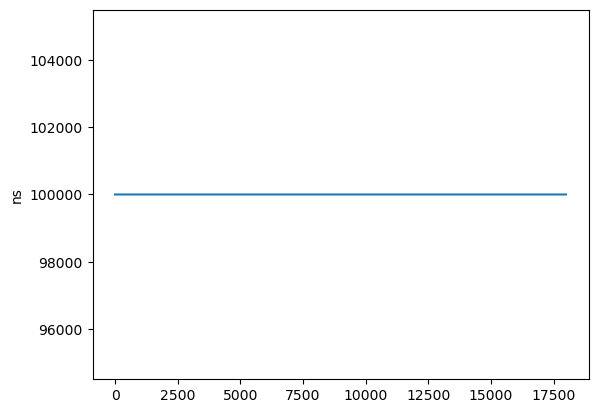

In [4]:
# check that the timebase looks good: should be constant 100 ms delay between timestamps
timestamp = pl_data["datetime"]

plt.figure()
plt.plot([i for i in (timestamp[2:-1].to_numpy()-timestamp[1:-2].to_numpy())])
plt.ylabel("ns")
plt.show()

In [5]:
# Run the exact same kalman filter as used by the OMB
# see: https://www.mdpi.com/2076-3263/12/3/110
# see: https://github.com/jerabaul29/OpenMetBuoy-v2021a/blob/63cbad7be45624d453c6f8127df181cb1466d454/legacy_firmware/firmware/standard_gps_waves_drifter/imu_manager.cpp#L359-L401

PI = 3.1415926535
axis_euler = 'xyz'
crrt_IMU = "VN1002"

# documentation for the filter; see: https://github.com/gauteh/ahrs-fusion/blob/main/ahrs/nxp_impl.hpp

# in particular:
# @param sampleFrequency The sensor sample rate in herz (samples per second)
# here, 10 Hz
nxp_filter = NxpFusion.new(10)

# assume start vertical - this cannot be too wrong
nxp_filter.set_quaternion([0., 0., 0., 1.])

# run the filter and store the quaternion at each step
# we do not trust the magnetometer, so just set these readings to 0.0f to ignore it

# note that this is always tricky to get right, see the notes below...

# be careful about the units: the units expected by the Kalman filter are (from nxp_impl.hpp):
# 
# * @brief Updates the filter with new gyroscope, accelerometer, and
# * magnetometer data. For roll, pitch, and yaw the accelerometer values can be
# * either m/s^2 or g, but for linear acceleration they have to be in g.
# *
# * 9DOF orientation function implemented using a 12 element Kalman filter
# *
# * void fRun_9DOF_GBY_KALMAN(SV_9DOF_GBY_KALMAN_t *SV,
# * const AccelSensor_t *Accel, const MagSensor_t *Mag,
# * const GyroSensor_t *Gyro, const MagCalibration_t *MagCal)
# *
# * @param gx The gyroscope x axis. In DPS.
# * @param gy The gyroscope y axis. In DPS.
# * @param gz The gyroscope z axis. In DPS.
# * @param ax The accelerometer x axis. In g.
# * @param ay The accelerometer y axis. In g.
# * @param az The accelerometer z axis. In g.
# * @param mx The magnetometer x axis. In uT.
# * @param my The magnetometer y axis. In uT.
# * @param mz The magnetometer z axis. In uT.

# convert to the right units
# 1 g = 9.81 m/s/s
# - is because of the acceleration vs. the acceleration felt by the IMU: there is a sign between these 2...
ax = -pl_data[f"{crrt_IMU}_acc_x_m/s/s"].to_numpy() / 9.81
ay = -pl_data[f"{crrt_IMU}_acc_y_m/s/s"].to_numpy() / 9.81
az = -pl_data[f"{crrt_IMU}_acc_z_m/s/s"].to_numpy() / 9.81

# 1 DPS = (PI / 180.0) rad/s
gx = pl_data[f"{crrt_IMU}_ang_x_rad/s"].to_numpy() / (PI / 180.0)
gy = pl_data[f"{crrt_IMU}_ang_y_rad/s"].to_numpy() / (PI / 180.0)
gz = pl_data[f"{crrt_IMU}_ang_z_rad/s"].to_numpy() / (PI / 180.0)

# mag set to 0, to avoid confusing in the special case of nearly vertical magnetic field
if True:
    use_magnetometer = False
    mx = np.zeros(ax.shape)
    my = np.zeros(ax.shape)
    mz = np.zeros(ax.shape)

# mag from VN100
# this seems to really confuse the Kalman filter, as the field is nearly vertical in the Arctic...
# probably, the VN100 has smarter filters built in than the barebone AHRS kalman filter
if False:
    use_magnetometer = True
    # uT = 0.01 G
    mx = pl_data[f"{crrt_IMU}_mag_x_ga"].to_numpy() / (0.01)
    my = pl_data[f"{crrt_IMU}_mag_y_ga"].to_numpy() / (0.01)
    mz = pl_data[f"{crrt_IMU}_mag_z_ga"].to_numpy() / (0.01)

# apply the filter quaternion to the acceleration: get the NED acceleration

# pre-allocate the arrays
q = np.full((ax.size, 4), np.nan)
r_euler = np.full((ax.size, 3), np.nan)
acc_ned = np.full((ax.size, 3), np.nan)

q[0] = nxp_filter.quaternion

# run through the Kalman filter through the whole timeseries
for i in range(len(ax)-1):
    nxp_filter.update(gx[i], gy[i], gz[i], ax[i], ay[i], az[i], mx[i], my[i], mz[i])
    q[i+1] = nxp_filter.quaternion

    # permutation is because of conventions: scalar first vs. scalar last...
    r = R.from_quat([q[i+1, 1], q[i+1, 2], q[i+1, 3], q[i+1, 0]])
    r_euler[i] = r.as_euler(axis_euler, degrees=True)

    acc_ned[i+1] = r.apply((ax[i+1], ay[i+1], az[i+1])) * 9.81  # back to m/s/s

In [6]:
# write the vertical and horizontal accelerations
pl_data = pl_data.with_columns(pl.Series(acc_ned[:, 0]).alias(f"{crrt_IMU}_acc_n_m/s/s"))
pl_data = pl_data.with_columns(pl.Series(acc_ned[:, 1]).alias(f"{crrt_IMU}_acc_e_m/s/s"))
pl_data = pl_data.with_columns(pl.Series(acc_ned[:, 2]).alias(f"{crrt_IMU}_acc_d_m/s/s"))

# write the Euler rotation angles from the quaternion
for i in range(3):
    crrt_angle = axis_euler[i]
    pl_data = pl_data.with_columns(pl.Series(r_euler[:, i]).alias(f"{crrt_IMU}_kalmaneuler_{crrt_angle}_deg"))

# compute and write the Euler rotation angles from the acceleration
# this is valid for very small angles and small accelerations - just from projection of the vertical acceleration
pl_data = pl_data.with_columns(pl.Series(-pl_data[f"{crrt_IMU}_acc_y_m/s/s"] / 9.81 * (180.0 / PI)).alias(f"{crrt_IMU}_inversegravityeuler_x_deg"))
pl_data = pl_data.with_columns(pl.Series(pl_data[f"{crrt_IMU}_acc_x_m/s/s"] / 9.81 * (180.0 / PI)).alias(f"{crrt_IMU}_inversegravityeuler_y_deg"))

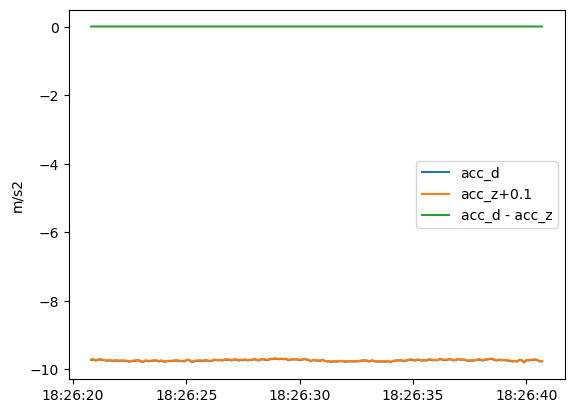

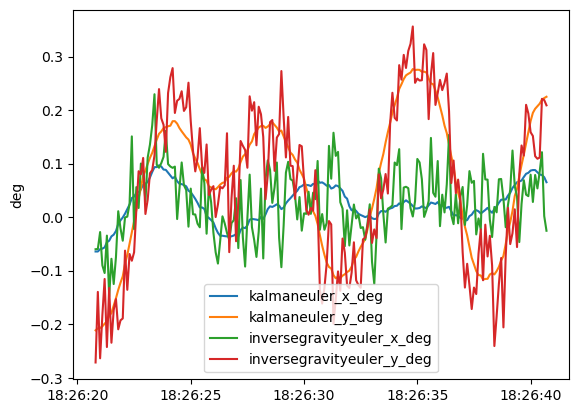

In [7]:
# plot some data
# check that the Kalman filter does it job correctly: right shape of the curves, smoothed output since it removes some of the random noise

# shorter x range, otherwise cannot see anything
start_plot = 2000
end_plot = start_plot + 200

# in this case, the buoy is nearly horizontal, so acc_z and acc_d are nearly the same
plt.figure()
plt.plot(pl_data["datetime"][start_plot:end_plot], -pl_data[f"{crrt_IMU}_acc_d_m/s/s"][start_plot:end_plot], label="acc_d")
plt.plot(pl_data["datetime"][start_plot:end_plot], pl_data[f"{crrt_IMU}_acc_z_m/s/s"][start_plot:end_plot]+0.01, label="acc_z+0.1")
plt.plot(pl_data["datetime"][start_plot:end_plot], -pl_data[f"{crrt_IMU}_acc_d_m/s/s"][start_plot:end_plot]-pl_data[f"{crrt_IMU}_acc_z_m/s/s"][start_plot:end_plot]+0.01, label="acc_d - acc_z")
plt.ylabel("m/s2")
plt.legend()

# the X and Y frame of reference pitch angles should be very close to the ones given from the inversion of the gravity projection on the X and Y accelerations
# see: https://journals.ametsoc.org/view/journals/atot/34/5/jtech-d-16-0219.1.xml
# check this!
# NOTE: this only works if the order of the Euler rotations is such that z is last (i.e., 'xyz' for example);
#       for example, with 'zyx', the z rotation influences the y and x rotation values (non commutativity)

plt.figure()
plt.plot(pl_data["datetime"][start_plot:end_plot], pl_data[f"{crrt_IMU}_kalmaneuler_x_deg"][start_plot:end_plot], label="kalmaneuler_x_deg")
plt.plot(pl_data["datetime"][start_plot:end_plot], pl_data[f"{crrt_IMU}_kalmaneuler_y_deg"][start_plot:end_plot], label="kalmaneuler_y_deg")
plt.plot(pl_data["datetime"][start_plot:end_plot], pl_data[f"{crrt_IMU}_inversegravityeuler_x_deg"][start_plot:end_plot], label="inversegravityeuler_x_deg")
plt.plot(pl_data["datetime"][start_plot:end_plot], pl_data[f"{crrt_IMU}_inversegravityeuler_y_deg"][start_plot:end_plot], label="inversegravityeuler_y_deg")
plt.ylabel("deg")
plt.legend()

plt.show()
